In [1]:
# ======================
# 1. SETUP & DATA LOADING
# ======================

## IMPORTANT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler



LOAD THE DATASET


In [2]:
# load the dataset
df=pd.read_csv("/content/A.csv")
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,1999-11-18 00:00:00-05:00,27.708214,30.448590,24.358870,26.794758,62546380,0.0,0.0
1,1999-11-19 00:00:00-05:00,26.147735,26.185797,24.244699,24.587246,15234146,0.0,0.0
2,1999-11-22 00:00:00-05:00,25.158145,26.794758,24.396931,26.794758,6577870,0.0,0.0
3,1999-11-23 00:00:00-05:00,25.881299,26.566393,24.358870,24.358870,5975611,0.0,0.0
4,1999-11-24 00:00:00-05:00,24.435000,25.538762,24.358877,25.005911,4843231,0.0,0.0


In [3]:
print(df.describe())


              Open         High          Low        Close        Volume  \
count  5998.000000  5998.000000  5998.000000  5998.000000  5.998000e+03   
mean     45.199962    45.760230    44.631428    45.206216  3.400332e+06   
std      38.691668    39.069778    38.268821    38.671874  2.418333e+06   
min       6.515998     6.777857     6.394204     6.607345  2.719000e+05   
25%      19.639343    19.925652    19.426195    19.684793  1.891100e+06   
50%      28.441159    28.806308    28.047904    28.417050  2.894629e+06   
75%      61.746157    62.731951    61.060984    61.834909  4.231536e+06   
max     177.025688   177.312042   174.942191   177.025681  6.254638e+07   

         Dividends  Stock Splits  
count  5998.000000   5998.000000  
mean      0.001341      0.000233  
std       0.023099      0.018051  
min       0.000000      0.000000  
25%       0.000000      0.000000  
50%       0.000000      0.000000  
75%       0.000000      0.000000  
max       1.471388      1.398000  


In [4]:
# Display the first few rows
print(df.head())

# Get basic info about the dataset
print(df.info())


                        Date       Open       High        Low      Close  \
0  1999-11-18 00:00:00-05:00  27.708214  30.448590  24.358870  26.794758   
1  1999-11-19 00:00:00-05:00  26.147735  26.185797  24.244699  24.587246   
2  1999-11-22 00:00:00-05:00  25.158145  26.794758  24.396931  26.794758   
3  1999-11-23 00:00:00-05:00  25.881299  26.566393  24.358870  24.358870   
4  1999-11-24 00:00:00-05:00  24.435000  25.538762  24.358877  25.005911   

     Volume  Dividends  Stock Splits  
0  62546380        0.0           0.0  
1  15234146        0.0           0.0  
2   6577870        0.0           0.0  
3   5975611        0.0           0.0  
4   4843231        0.0           0.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5998 entries, 0 to 5997
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          5998 non-null   object 
 1   Open          5998 non-null   float64
 2   High          5998 non-nul

Handle Null Values

In [5]:
# Check for null values
print(df.isnull().sum())

# Option 1: Drop rows with null values (if only a few are present)
df.dropna(inplace=True)

# Option 2: Fill null values with appropriate statistics (e.g., mean, median)
# df['Close'].fillna(data['Close'].mean(), inplace=True)

# Recheck for null values
print(df.isnull().sum())


Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64
Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64


Exploratory Data Analysis (EDA)

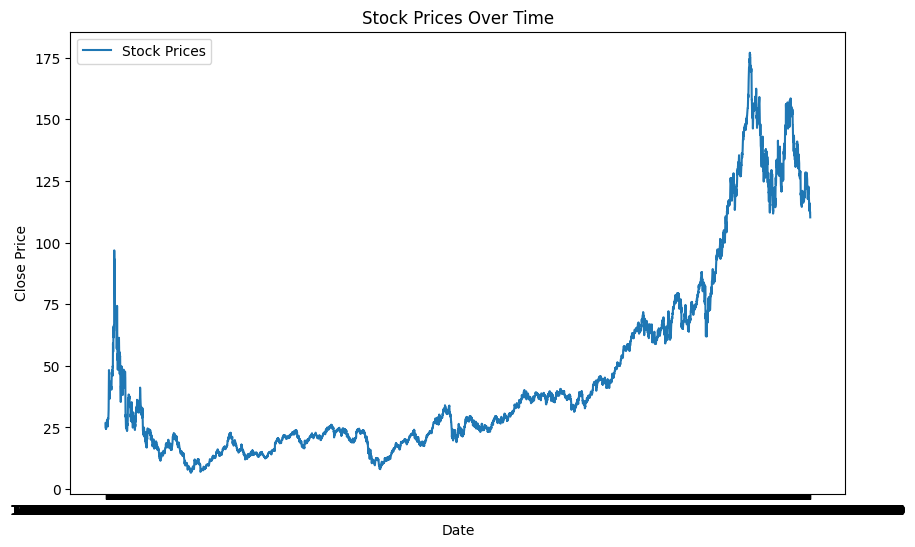

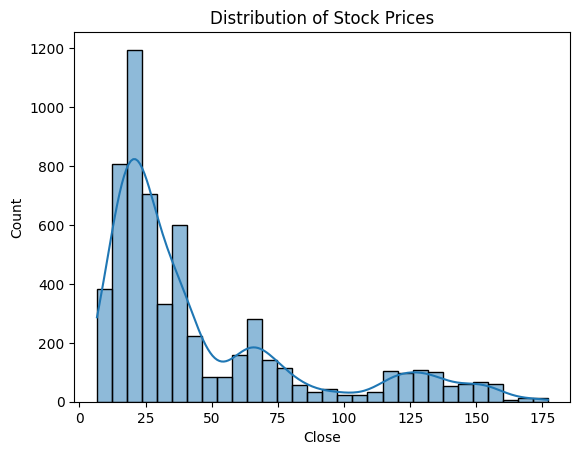

In [6]:
# Line plot of stock prices
plt.figure(figsize=(10, 6))
plt.plot(df['Date'], df['Close'], label='Stock Prices')
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Stock Prices Over Time")
plt.legend()
plt.show()

# Distribution of stock prices
sns.histplot(df['Close'], bins=30, kde=True)
plt.title("Distribution of Stock Prices")
plt.show()


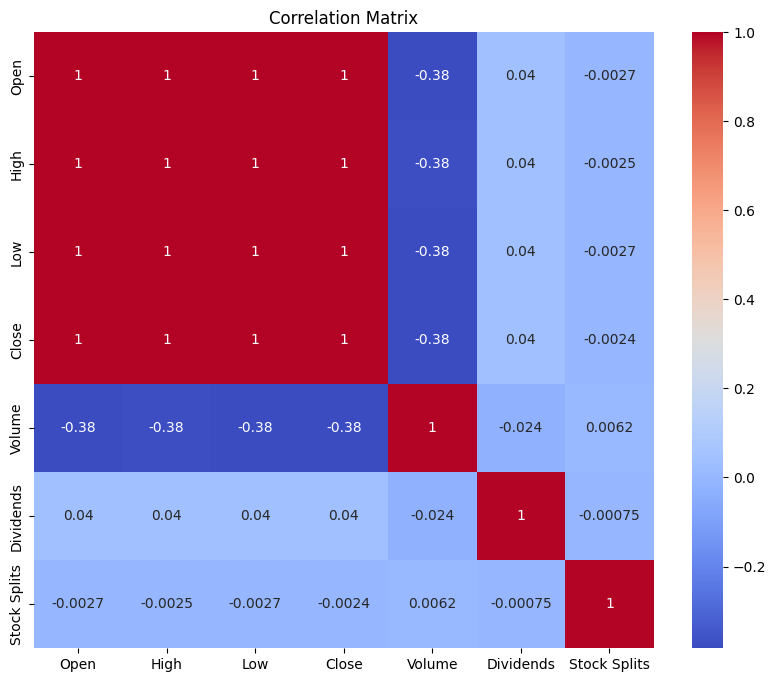

In [7]:

# 3. Correlation heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

 Outlier Treatment

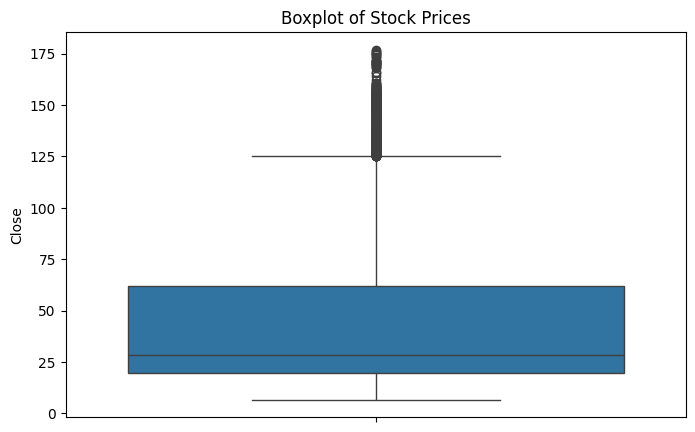

In [8]:
# Identify outliers using boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(df['Close'])
plt.title("Boxplot of Stock Prices")
plt.show()


In [9]:
# Remove outliers (Example: Using the IQR method)
Q1 = df['Close'].quantile(0.25)
Q3 = df['Close'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
data = df[(df['Close'] >= lower_bound) & (df['Close'] <= upper_bound)]
data

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,1999-11-18 00:00:00-05:00,27.708214,30.448590,24.358870,26.794758,62546380,0.0,0.0
1,1999-11-19 00:00:00-05:00,26.147735,26.185797,24.244699,24.587246,15234146,0.0,0.0
2,1999-11-22 00:00:00-05:00,25.158145,26.794758,24.396931,26.794758,6577870,0.0,0.0
3,1999-11-23 00:00:00-05:00,25.881299,26.566393,24.358870,24.358870,5975611,0.0,0.0
4,1999-11-24 00:00:00-05:00,24.435000,25.538762,24.358877,25.005911,4843231,0.0,0.0
...,...,...,...,...,...,...,...,...
5993,2023-09-15 00:00:00-04:00,114.430000,121.919998,113.430000,115.910004,6882600,0.0,0.0
5994,2023-09-18 00:00:00-04:00,115.000000,115.000000,112.660004,112.690002,1818000,0.0,0.0
5995,2023-09-19 00:00:00-04:00,112.370003,113.230003,111.720001,112.309998,2222400,0.0,0.0
5996,2023-09-20 00:00:00-04:00,113.080002,113.470001,112.169998,112.470001,1744900,0.0,0.0


Feature Engineering

In [10]:

if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], utc=True)
    df.set_index('Date', inplace=True)

Split the Dataset

In [11]:
# ======================
# 5. DATA PREPROCESSING
# ======================

print("\n=== DATA PREPROCESSING ===")

# Define features and target
features = ['Open', 'High', 'Low', 'Close', 'Volume']
X = df[features]
y = df['Close']  # Predicting closing price

# Split data (note: for time series, we should use TimeSeriesSplit)
# But for simplicity, we'll use train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False)


=== DATA PREPROCESSING ===


Train the Model

In [12]:
# Initialize and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()


Make Predictions

In [13]:
# Predict on test data
y_pred = model.predict(X_test)


In [18]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation:")
print(f"Mean Squared Error: {mse}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

Model Evaluation:
Mean Squared Error: 4.020006828450653e-17
Mean Squared Error: 0.00
Root Mean Squared Error: 0.00
R² Score: 1.00


Visualization

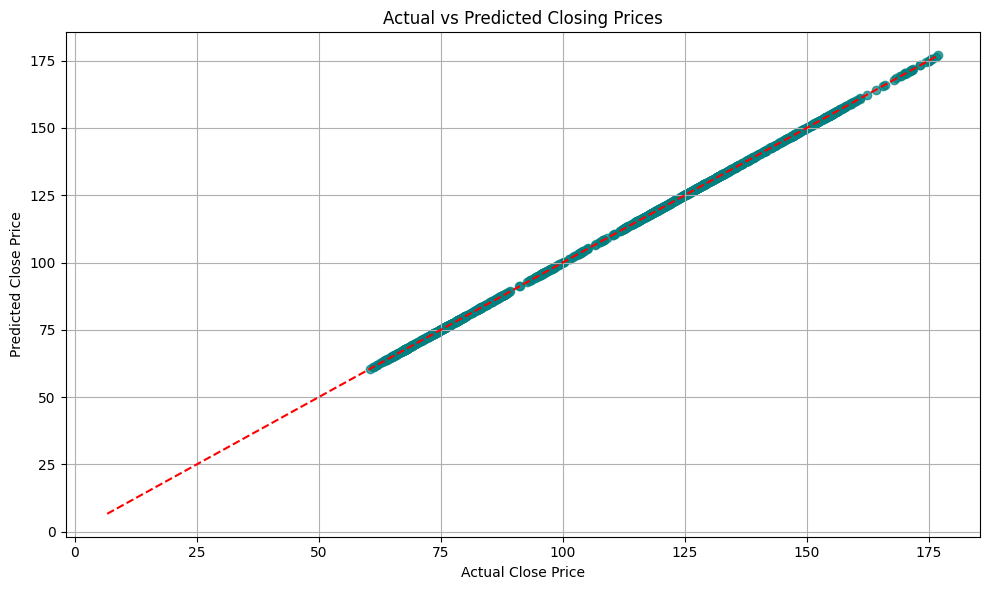

In [19]:
'''plt.figure(figsize=(10, 10))
plt.scatter(X_test, y_test, label="Actual Prices", color="green")
plt.scatter(X_test, y_pred, label="Predicted Prices", color="red")
plt.plot(X, model.predict(X), color="black", label="Regression Line")
plt.legend()
plt.xlabel("Days")
plt.ylabel("Stock Price")
plt.title("Stock Price Prediction")
plt.show()'''
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("Actual vs Predicted Closing Prices")
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
# List of features to plot against Close
features = ['Open', 'High', 'Low', 'Volume']

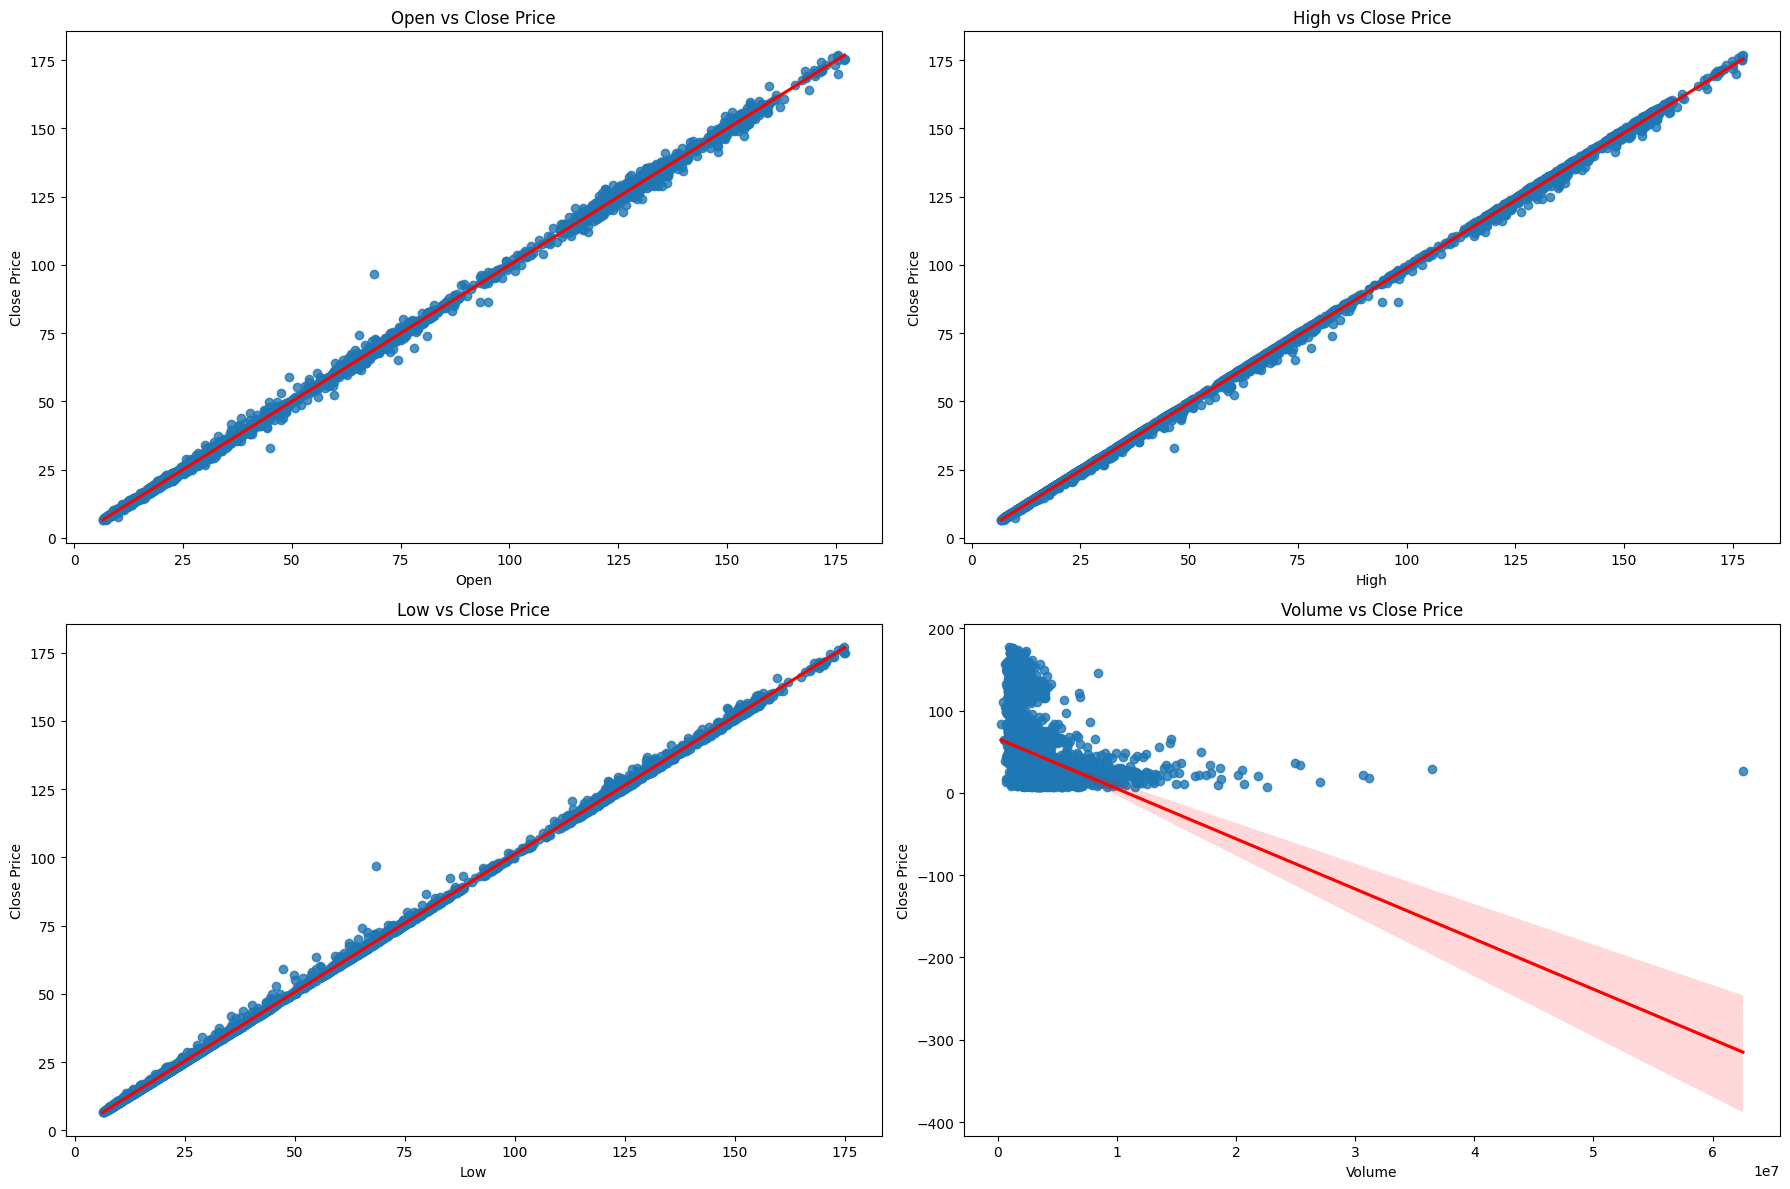

In [21]:
# Create scatter plots with regression lines
plt.figure(figsize=(18, 12))

for idx, feature in enumerate(features):
    plt.subplot(2, 2, idx+1)
    sns.regplot(x=df[feature], y=df['Close'], line_kws={"color": "red"})
    plt.title(f"{feature} vs Close Price")
    plt.xlabel(feature)
    plt.ylabel("Close Price")

plt.tight_layout()
plt.show()

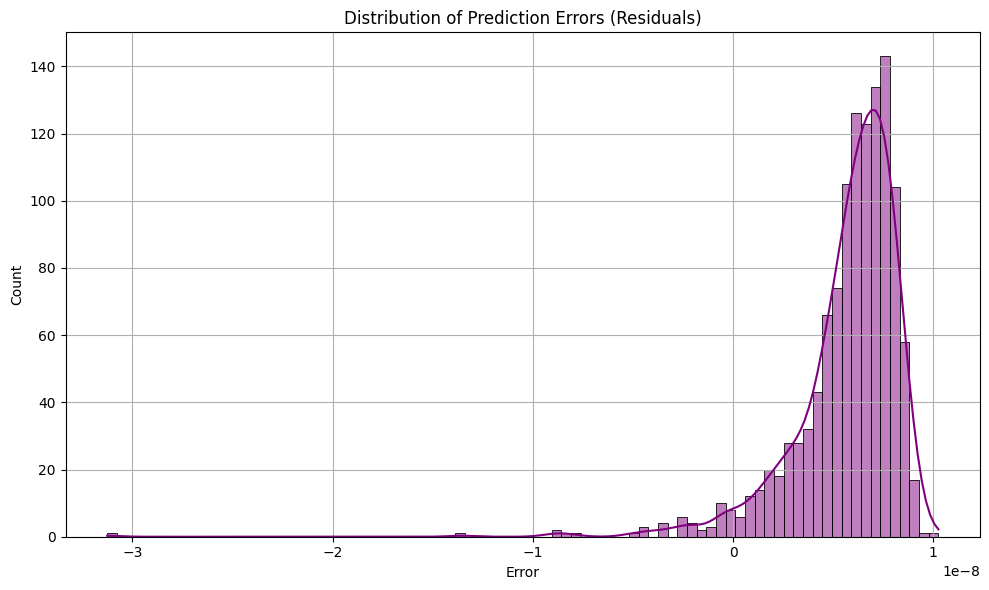

In [24]:
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='purple')
plt.title("Distribution of Prediction Errors (Residuals)")
plt.xlabel("Error")
plt.grid(True)
plt.tight_layout()
plt.show()